In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('../DataSets/Fashion_Trends.csv')
df

,Brand,Description,Product_ID,Discount_Price,Original_Price,Gender,Category,Discounted_amount,Discount_Percentage,Product_Name,Price_Segment,Discount_Tier
0,performax,Typographic Print Track Pants with Insert Pockets,441136763008,974,1299,Men,Activewear,325,25.02,Track Pants,Mid (₹500–₹1499),Moderate (20-40%)
1,performax,Low-Top Lace-Up Sports Shoes,450137679013,1499,1499,Men,Activewear,0,0.00,Sports Shoes,Mid (₹500–₹1499),No Discount
2,teamspirit,Colorblock Crew-Neck T-shirt,441133214008,461,549,Men,Activewear,88,16.03,Crew-Neck T-shirt,Mid (₹500–₹1499),Light (10-20%)
3,performax,Camouflage Print Joggers with Insert Pockets,441134776020,1189,1699,Men,Activewear,510,30.02,Print Joggers,Premium (₹1500–₹3999),Moderate (20-40%)
4,teamspirit,Reflective Colourblock Crew-Neck T-shirt,441136539020,425,599,Men,Activewear,174,29.05,Crew-Neck T-shirt,Mid (₹500–₹1499),Moderate (20-40%)
...,...,...,...,...,...,...,...,...,...,...,...,...
31577,ajio,Printed Top with Raglan Sleeves,460328028004,1299,1299,Women,Westernwear,0,0.00,Printed Top,Mid (₹500–₹1499),No Discount
31578,ajio,Striped Cropped Pants with Belt,460328036004,2099,2099,Women,Westernwear,0,0.00,Cropped Pants,Premium (₹1500–₹3999),No Discount
31579,ajio,Striped City Shorts with Belt,460328005002,1499,1499,Women,Westernwear,0,0.00,City Shorts,Mid (₹500–₹1499),No Discount
31580,ajio,Denim Jacket with Frayed Hemline,460328651009,2999,2999,Women,Westernwear,0,0.00,Denim Jacket,Premium (₹1500–₹3999),No Discount


## **Data Preparation:**

### **Check and handle missing values**

In [4]:
df.isnull().sum()

Brand                  0
Description            0
Product_ID             0
Discount_Price         0
Original_Price         0
Gender                 0
Category               0
Discounted_amount      0
Discount_Percentage    0
Product_Name           0
Price_Segment          0
Discount_Tier          0
dtype: int64

## **Ensure datatypes are in correct format**

In [5]:
df.dtypes

Brand                   object
Description             object
Product_ID               int64
Discount_Price           int64
Original_Price           int64
Gender                  object
Category                object
Discounted_amount        int64
Discount_Percentage    float64
Product_Name            object
Price_Segment           object
Discount_Tier           object
dtype: object

## **Exploratory Data Analysis (EDA):**

### **Distribution of numerical features**

In [114]:
df.describe()

,Product_ID,Discount_Price,Original_Price,Discounted_amount,Discount_Percentage
count,3.158200e+04,31582.000000,31582.000000,31582.000000,31582.000000
mean,4.439001e+11,929.759832,1418.094769,488.334938,32.979031
std,5.715579e+09,727.207471,945.684511,544.062245,24.667178
min,4.200088e+11,75.000000,149.000000,0.000000,0.000000
25%,4.411142e+11,479.000000,799.000000,0.000000,0.000000
50%,4.411360e+11,735.000000,1299.000000,356.000000,35.040000
75%,4.501273e+11,1199.000000,1799.000000,749.000000,50.930000
max,4.608526e+11,16999.000000,19999.000000,11999.000000,85.010000


## **Frequency distribution of categorical features**

In [115]:
df.Category.unique()

array(['Activewear', 'Bottomwear', 'Footwear', 'Innerwear', 'Topwear',
       'Ethnicwear', 'Fusionwear', 'Lingerie', 'Westernwear'],
      dtype=object)

In [116]:
df.Category.nunique()

9

In [117]:
df.Category.value_counts()

Category
Topwear        7110
Westernwear    6641
Footwear       6030
Ethnicwear     5265
Bottomwear     2984
Activewear     2134
Fusionwear      997
Lingerie        325
Innerwear        96
Name: count, dtype: int64

In [118]:
df.Product_Name.unique()

array(['Track Pants', 'Sports Shoes', 'Crew-Neck T-shirt', ...,
       'Drop-Shoulder Shirt', 'Cold-Shoulder Shirt',
       'Polka-Dotted Trousers'], dtype=object)

In [119]:
df.Product_Name.nunique()

1799

In [120]:
df.Product_Name.value_counts()

Product_Name
Crew-Neck T-shirt    2312
Straight Kurta       2126
Fit Shirt            2117
Polo T-shirt         1126
A-line Kurta          803
                     ... 
black xs                1
Front Top               1
Washed Dungarees        1
Checked Jeans           1
Fitted Leggings         1
Name: count, Length: 1799, dtype: int64

In [121]:
df.Brand.unique()

array(['performax', 'teamspirit', 'puma', 'dnmx', 'proline', 'aero-jeans',
       'lag', 'fila', 'cross-trekkers', 'allen-solly', 'skechers',
       'airwalk', 'umbro', 'dexter', 'saucony', 'monza', 'chromozome',
       'gola', 'netplay', 'john-players-jeans', 'john-players',
       'lee-cooper', 'ecko', 'denizen-from-levis', 'sin',
       'produkt-by-jack-jones', 'duke', 'altheory-sport', 'jockey',
       'octave', 'altheory', 'network', 'disney', 'warner-brothers',
       'ecko-unltd', 'indian-terrain', 'uniquest', 'monte-carlo',
       'only-vimal-apparel', 'parx', 'killer', 'first-class', 'basics',
       'ajio', 'u-s-polo-assn-', 'indigo-nation', 'crimsoune-club',
       'pepe-jeans', 'integriti', 'monte-bianco', 'wrangler', 'arrow',
       'christofano', 'frisbee', 'woodland', 'schumann', 'crocs',
       'adidas', 'inblu', 'schumann-premium', 'buckaroo', 'hunters-bay',
       'clarks', 'id', 'reebok', 'nike', 'attilio', 'nez',
       'louis-philippe', 'red-chief', 'alberto-torres

In [122]:
df.Brand.nunique()

191

In [123]:
df.Brand.value_counts()

Brand
performax             3029
teamspirit            1908
dnmx                  1757
netplay               1698
avaasa-mix-n-match    1507
                      ... 
jublee                   1
monrow                   1
bon-bon                  1
awb                      1
avaasa-workwear          1
Name: count, Length: 191, dtype: int64

## **Identify outliers in Price and Discount**

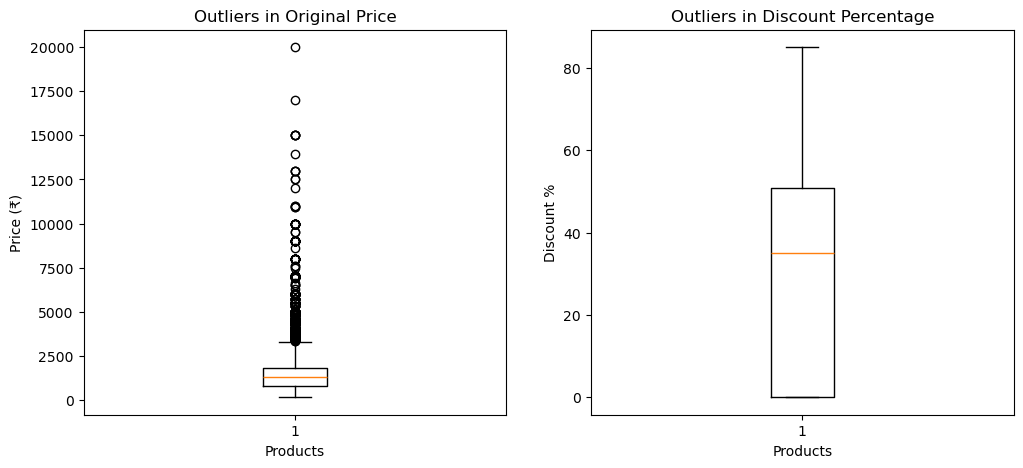

In [141]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.boxplot(df["Original_Price"])
plt.title("Outliers in Original Price")
plt.xlabel("Products")
plt.ylabel("Price (₹)")

plt.subplot(1,2,2)
plt.boxplot(df["Discount_Percentage"])
plt.title("Outliers in Discount Percentage")
plt.xlabel("Products")
plt.ylabel("Discount %")
plt.show()

## **Brand & Category Analysis:**

### **Top Brands:**

### **Which brands have the most products?**

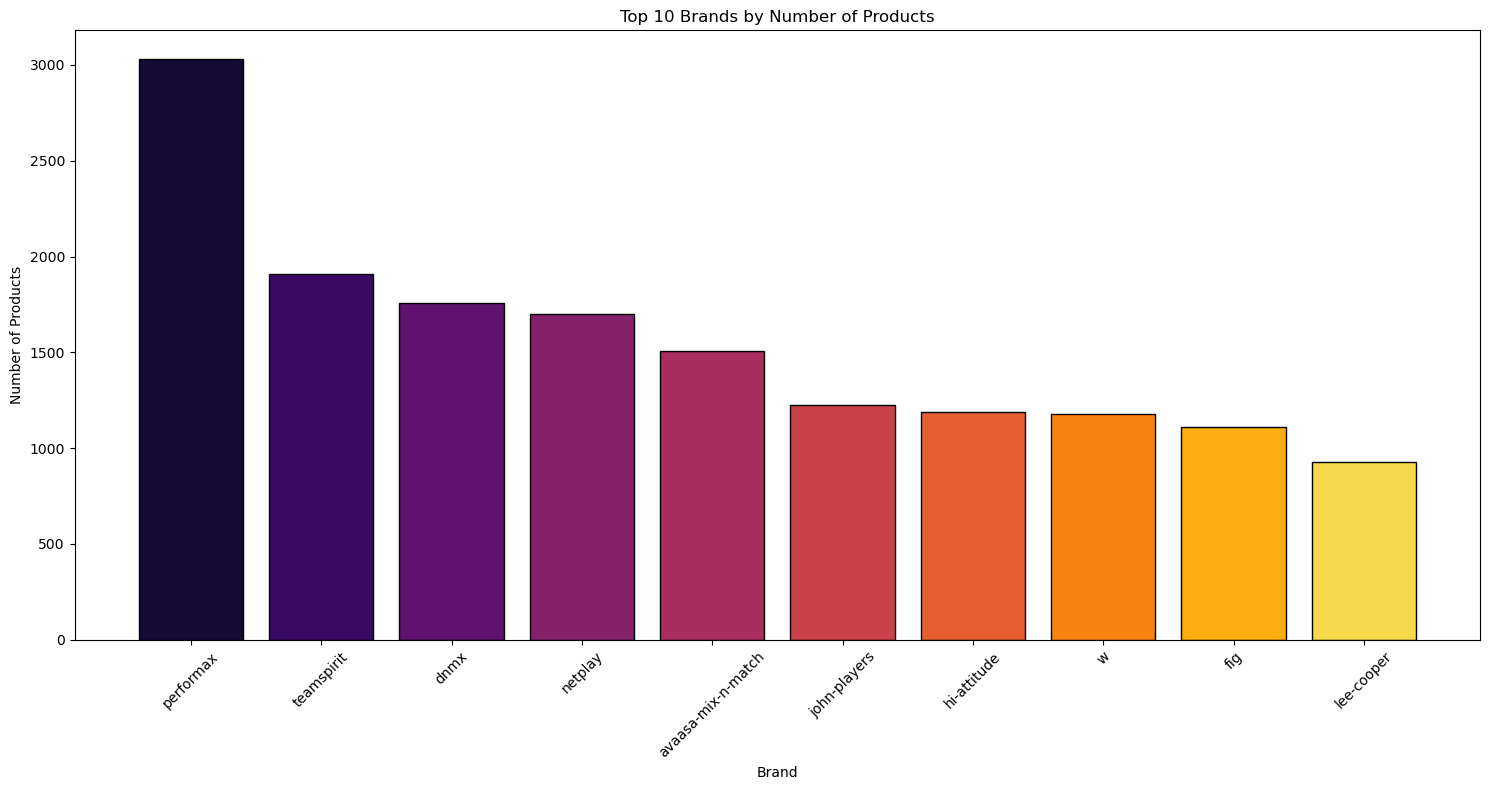

In [125]:
brand_counts = df.Brand.value_counts().reset_index().head(10)
brand_counts.columns = ['Brand','Product_Count']

plt.figure(figsize=(15,8))
plt.bar(brand_counts["Brand"], brand_counts["Product_Count"], color=sb.color_palette("inferno", len(brand_counts)),edgecolor='black')
plt.title("Top 10 Brands by Number of Products")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Category Analysis:**

### **Which categories dominate overall?**

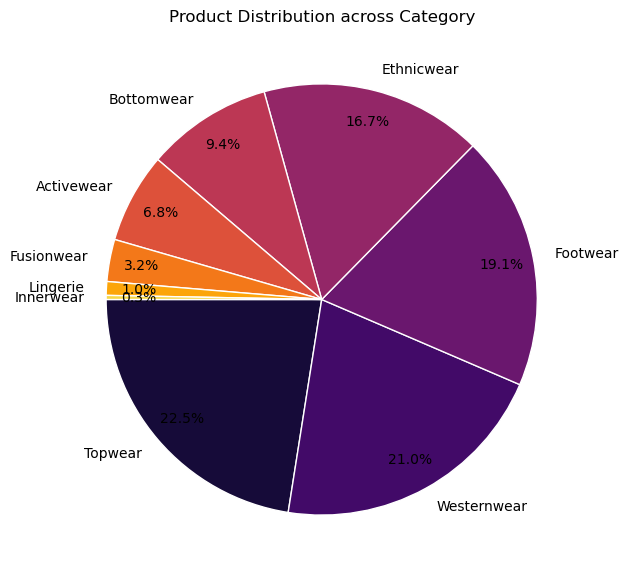

In [126]:
category_counts = df["Category"].value_counts().reset_index()
category_counts.columns = ["Category", "Product_Count"]

plt.figure(figsize=(14,7))
plt.pie(category_counts["Product_Count"], labels=category_counts["Category"],autopct='%1.1f%%',startangle=180,
           pctdistance=0.85,labeldistance=1.1,wedgeprops={'linewidth':1, 'edgecolor':'white'},
           colors=sb.color_palette("inferno", len(category_counts)))
plt.title("Product Distribution across Category")
plt.show()

## **Category vs Price Segment:**

### **Which categories dominate in Budget, Mid, Premium, Luxury?**

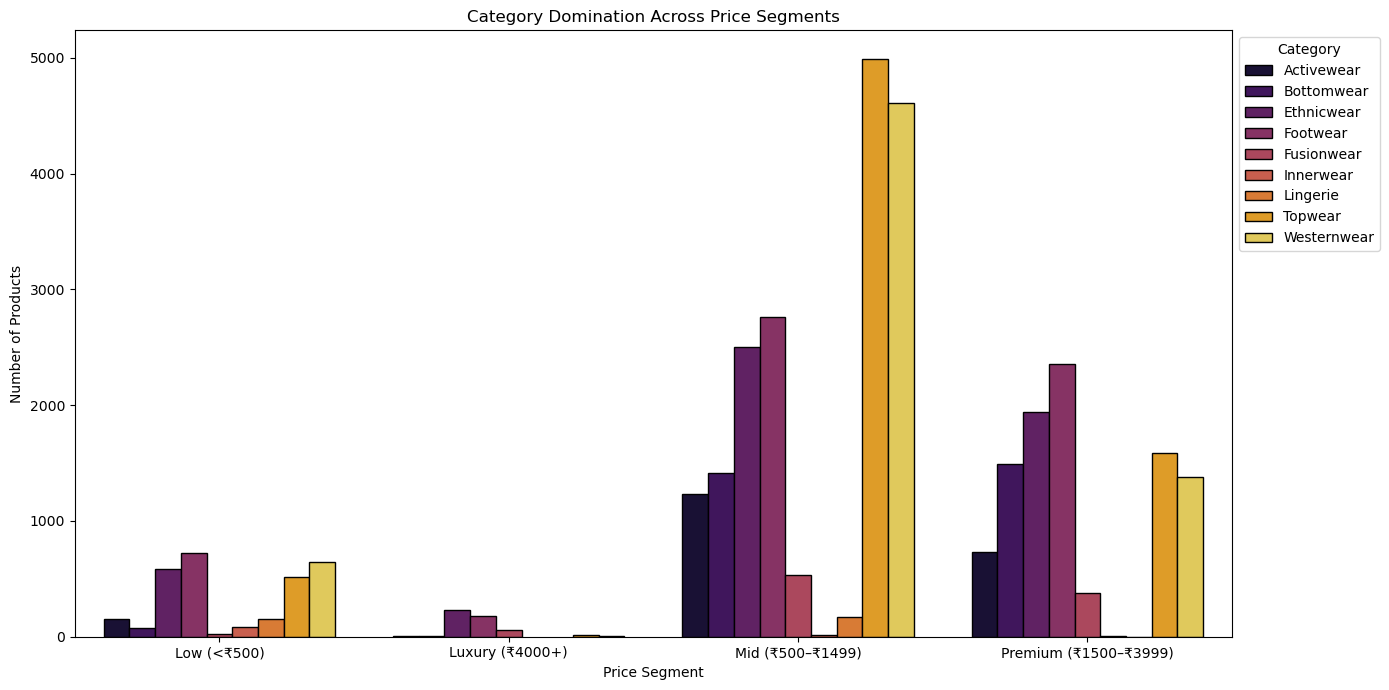

In [127]:
price_category_counts = df.groupby(['Price_Segment','Category']).size().reset_index(name="Count")

plt.figure(figsize=(14,7))
sb.barplot(x=price_category_counts.Price_Segment, y=price_category_counts.Count, 
            hue=price_category_counts.Category, palette="inferno",edgecolor='black')

plt.title("Category Domination Across Price Segments")
plt.xlabel("Price Segment")
plt.ylabel("Number of Products")
plt.legend(title="Category", bbox_to_anchor=(1.0, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Product Type Analysis:**

### **Which product types are most common?**

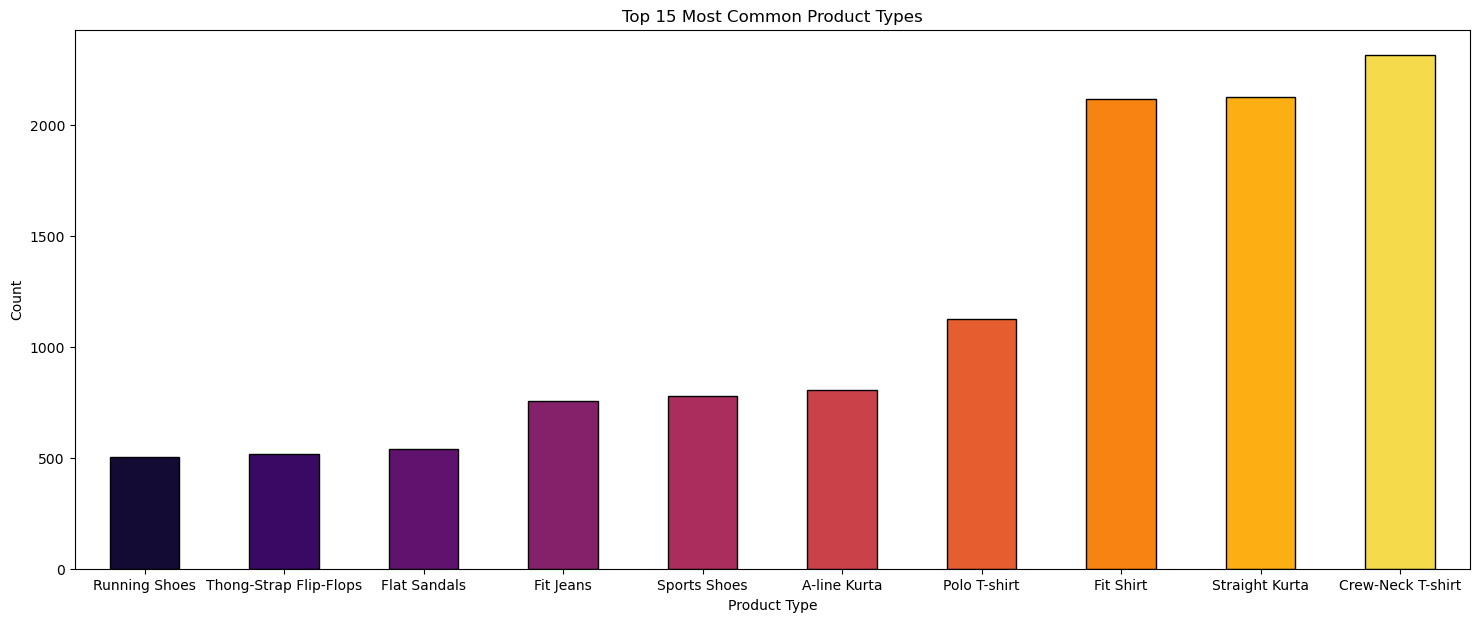

In [128]:
product_counts=df.Product_Name.value_counts().head(10)
plt.figure(figsize=(18,7))
product_counts.sort_values().plot(kind="bar", color=sb.color_palette("inferno", len(product_counts)),edgecolor="black")
plt.title("Top 15 Most Common Product Types")
plt.xlabel("Product Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## **Compare product type distribution across genders.**

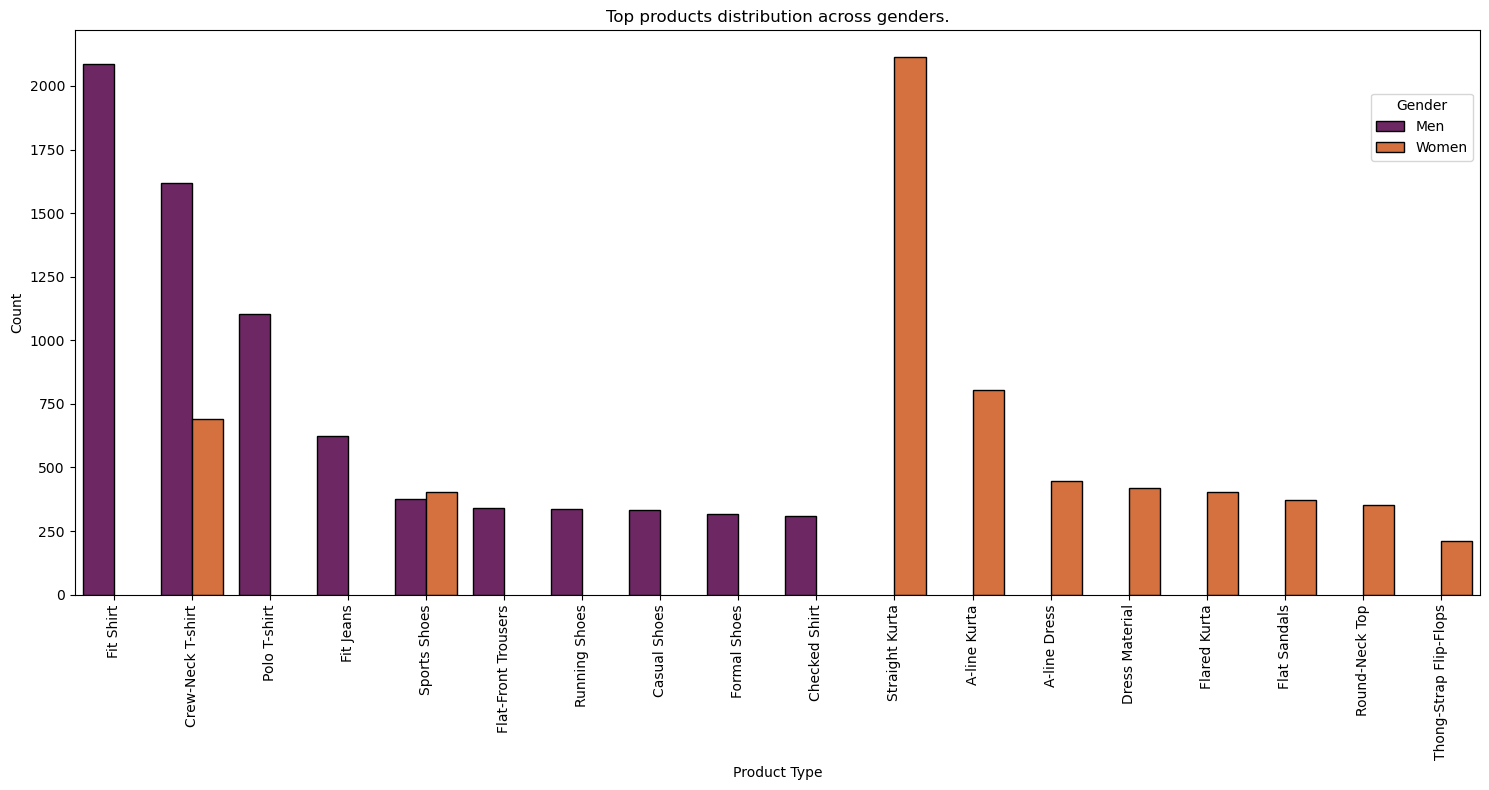

In [129]:
top_products_across_gender = df.groupby(['Gender','Product_Name']).size().reset_index(name='Count').sort_values(['Gender','Count'],ascending=[True,False])
top_products_across_gender = top_products_across_gender.groupby('Gender').head(10)

plt.figure(figsize=(15,8))
sb.barplot(y=top_products_across_gender.Count, x=top_products_across_gender.Product_Name,
             hue=top_products_across_gender.Gender, dodge=True, palette="inferno",edgecolor='black')

plt.title("Top products distribution across genders.")
plt.xlabel("Product Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.legend(title="Gender",bbox_to_anchor=(1.0,0.9))
plt.tight_layout()
plt.show()

## **Identify top product types within each category**

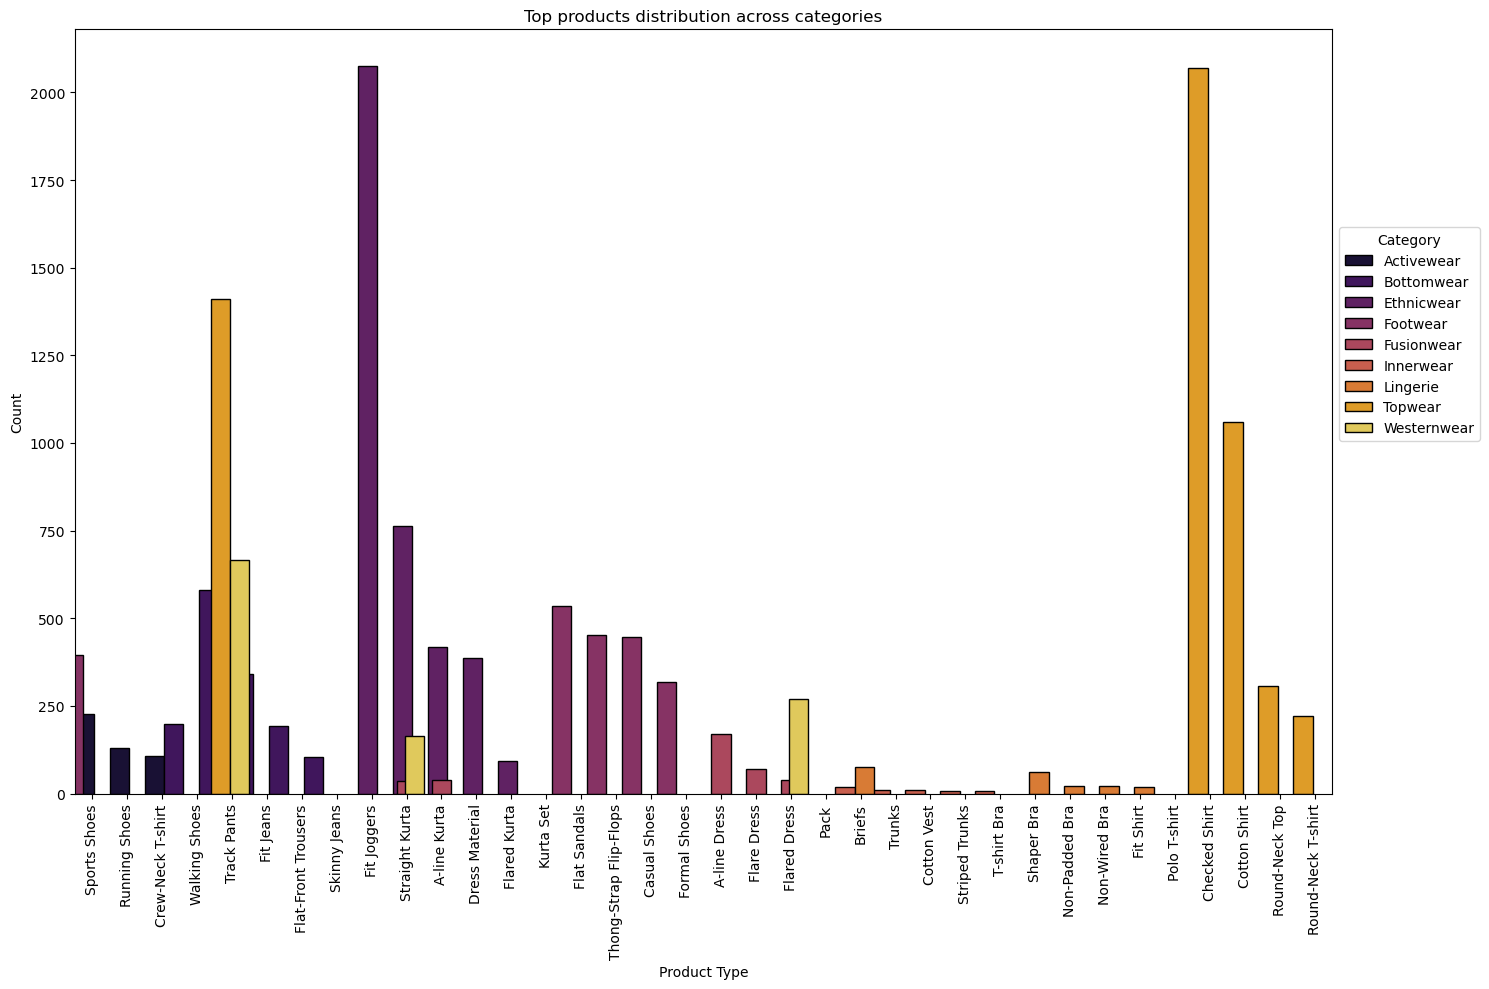

In [130]:
top_products_across_category = df.groupby(['Category','Product_Name']).size().reset_index(name='Count').sort_values(['Category','Count'],ascending=[True,False])
top_products_across_category = top_products_across_category.groupby('Category').head(5)

plt.figure(figsize=(15,10))
sb.barplot(y=top_products_across_category.Count, x=top_products_across_category.Product_Name,
             hue=top_products_across_category.Category, dodge=True, palette="inferno",errorbar=None,width=5.0,edgecolor='black')

plt.title("Top products distribution across categories")
plt.xlabel("Product Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.legend(title="Category",bbox_to_anchor=(1.0,0.75))
plt.tight_layout()
plt.show()

## **Discount Analysis:**

### **Discount Tier Comparison:**

### **How many products fall into each discount tier?**

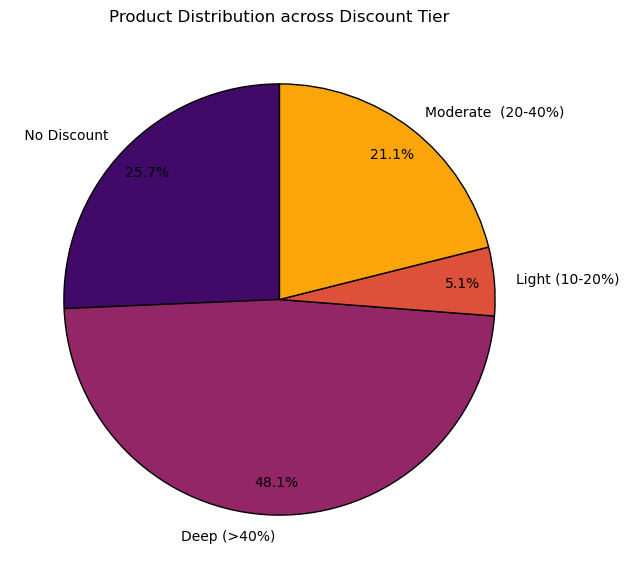

In [131]:
discount_counts = df["Discount_Tier"].value_counts().sort_index()
plt.figure(figsize=(8,7))
discount_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,pctdistance=0.85,labeldistance=1.1,
wedgeprops={'linewidth':1, 'edgecolor':'black'},colors=sb.color_palette("inferno", len(discount_counts)))
plt.title("Product Distribution across Discount Tier")
plt.ylabel("")
plt.show()

## **Discount % vs Product Type:**

### **Which product types get the highest average discount?**

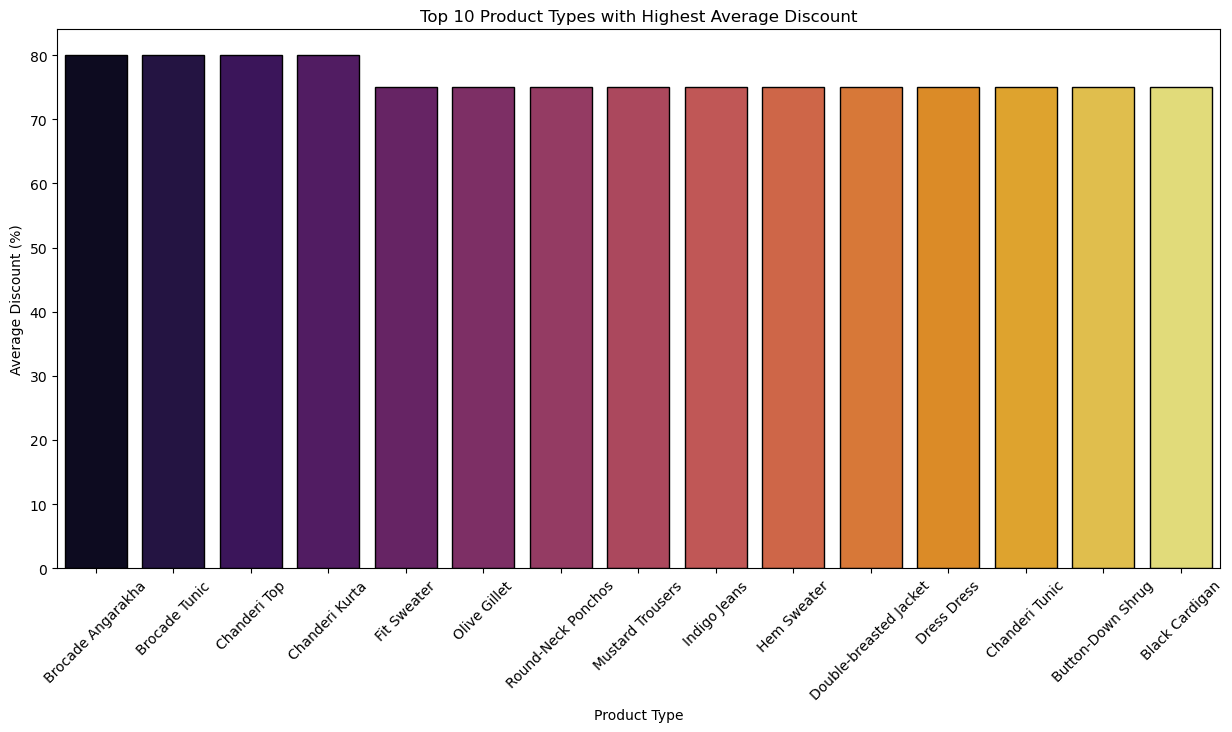

In [132]:
avg_discount = df.groupby("Product_Name")["Discount_Percentage"].mean().reset_index().sort_values("Discount_Percentage", ascending=False).head(15)
plt.figure(figsize=(15,7))
sb.barplot(x=avg_discount.Product_Name, y=avg_discount.Discount_Percentage,palette='inferno',edgecolor='black')
plt.title("Top 10 Product Types with Highest Average Discount")
plt.xlabel("Product Type")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=45)
plt.show()

## **Discounts Across Categories:**

### **Which categories rely most on heavy discounts?**

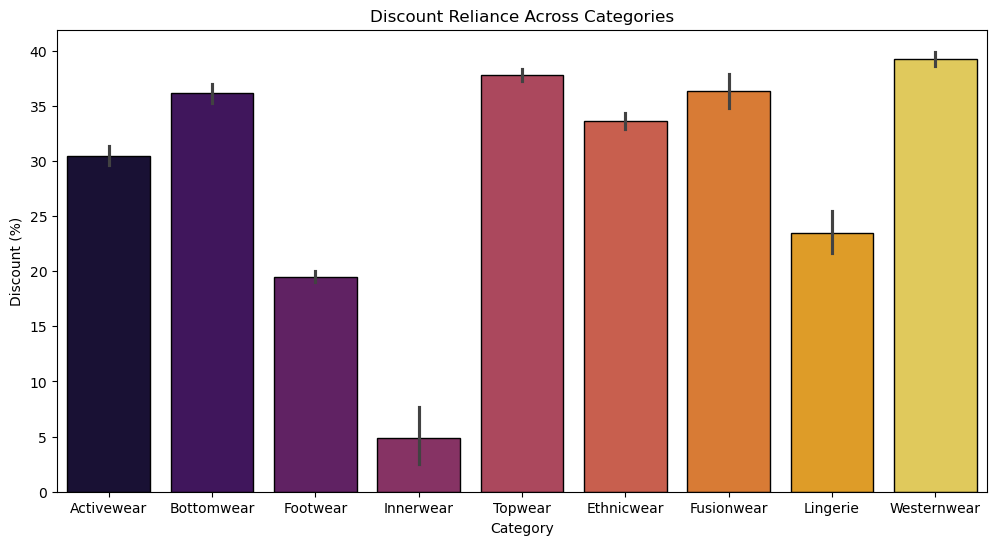

In [133]:
avg_discount_category = df.groupby("Category")["Discount_Percentage"].mean().reset_index().sort_values("Discount_Percentage", ascending=False)
plt.figure(figsize=(12,6))
sb.barplot(x=df.Category, y=df.Discount_Percentage, palette="inferno",edgecolor='black')
plt.title("Discount Reliance Across Categories")
plt.xlabel("Category")
plt.ylabel("Discount (%)")
plt.show()

## **Price vs Discount Analysis:**

### **Are higher-priced products more likely to have higher discounts?**

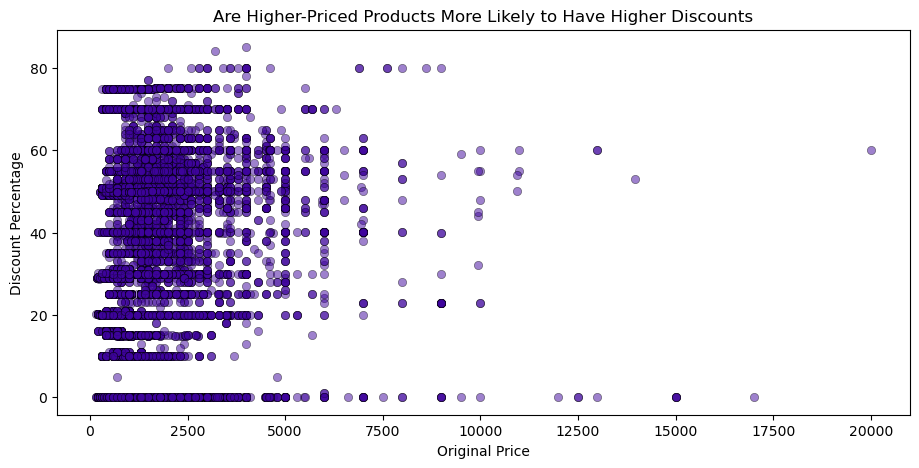

In [134]:
corr=df[['Original_Price','Discount_Percentage']].corr()
plt.figure(figsize=(11,5))
sb.scatterplot(data=df, x="Original_Price", y="Discount_Percentage", alpha=0.5,color=sb.color_palette("plasma", 10)[0],edgecolor='black')
plt.title("Are Higher-Priced Products More Likely to Have Higher Discounts")
plt.xlabel("Original Price")
plt.ylabel("Discount Percentage")
plt.show()

## **Gender-Based Preferences:**

### **Which categories and product types dominate for Men vs Women vs Kids?**

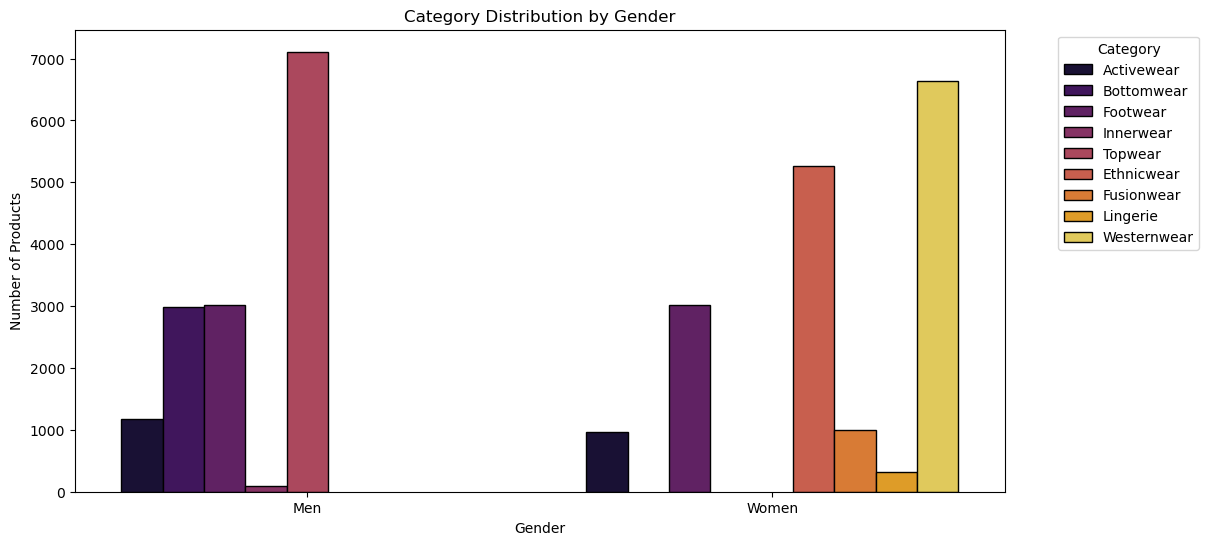

In [135]:
category_gender = df.groupby(["Gender", "Category"]).size().reset_index(name="Count").sort_values(["Gender","Count"], ascending=[True, False]).head(10)
product_gender = df.groupby(["Gender", "Product_Name"]).size().reset_index(name="Count").sort_values(["Gender","Count"], ascending=[True, False]).head(10)
plt.figure(figsize=(12,6))
sb.countplot(data=df, x="Gender", hue="Category",palette="inferno",edgecolor='black')
plt.title("Category Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Products")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## **Gender-wise average discount %**

In [136]:
gender_discount = df.groupby("Gender")["Discount_Percentage"].mean().reset_index().sort_values("Discount_Percentage", ascending=False)
print(gender_discount)

  Gender  Discount_Percentage
0    Men             33.31903
1  Women             32.69499


## **Identify whether men’s or women’s products are more discount-driven**

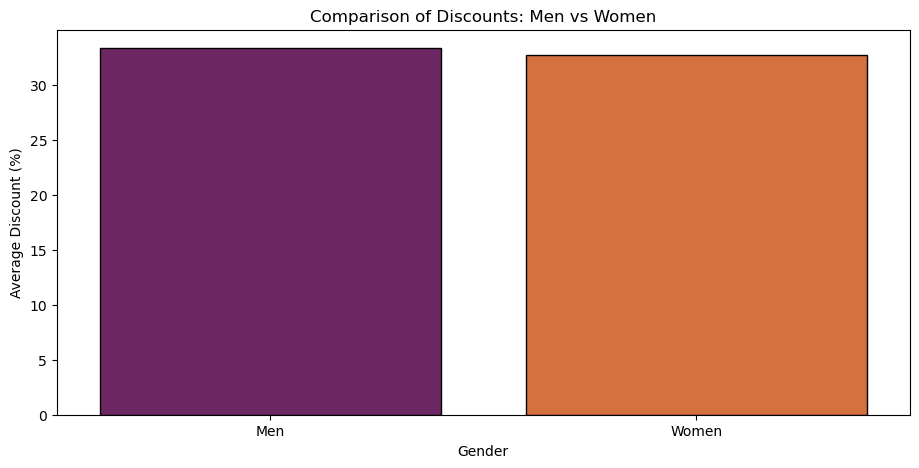

In [137]:
plt.figure(figsize=(11,5))
sb.barplot(x=gender_discount.Gender, y=gender_discount.Discount_Percentage, palette="inferno",edgecolor='black')
plt.title("Comparison of Discounts: Men vs Women")
plt.xlabel("Gender")
plt.ylabel("Average Discount (%)")
plt.show()

## **Price Segment Analysis**

### **Distribution of products across Budget, Mid, Premium, Luxury**

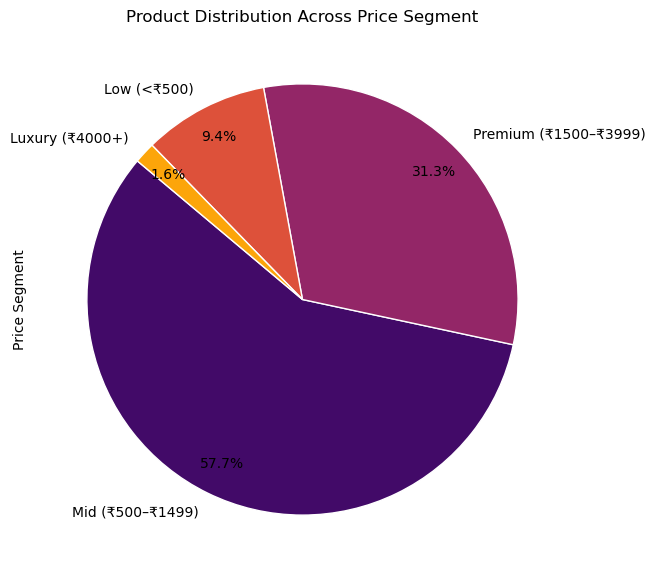

In [138]:
segment_counts = df["Price_Segment"].value_counts().reset_index()
segment_counts.columns = ["Price_Segment", "Product_Count"]
plt.figure(figsize=(8,7))
plt.pie(segment_counts["Product_Count"], labels=segment_counts["Price_Segment"], autopct='%1.1f%%',pctdistance=0.85,labeldistance=1.1,wedgeprops={'linewidth':1, 'edgecolor':'white'},
startangle=140,colors=sb.color_palette("inferno", len(segment_counts)))
plt.title("Product Distribution Across Price Segment")
plt.ylabel('Price Segment')
plt.show()

## **Which categories dominate in each segment?**

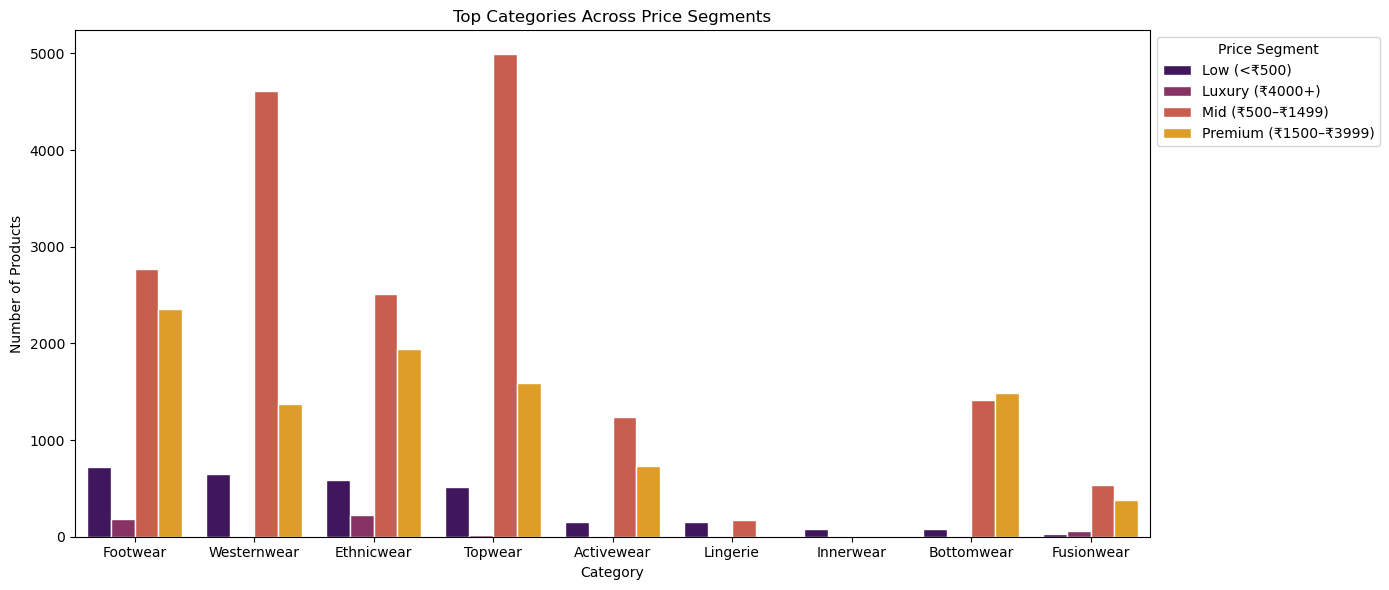

In [139]:
category_by_segment = df.groupby(["Price_Segment", "Category"]).size().reset_index(name="Count").sort_values(["Price_Segment","Count"], ascending=[True, False])

plt.figure(figsize=(14,6))
sb.barplot(x=category_by_segment.Category, y=category_by_segment.Count,
            hue=category_by_segment.Price_Segment,dodge=True,palette="inferno",edgecolor='white')
plt.title("Top Categories Across Price Segments")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.legend(title="Price Segment", bbox_to_anchor=(1.0,1), loc="upper left")
plt.tight_layout()
plt.show()

## **Compare Brand positioning (budget vs premium brands).**

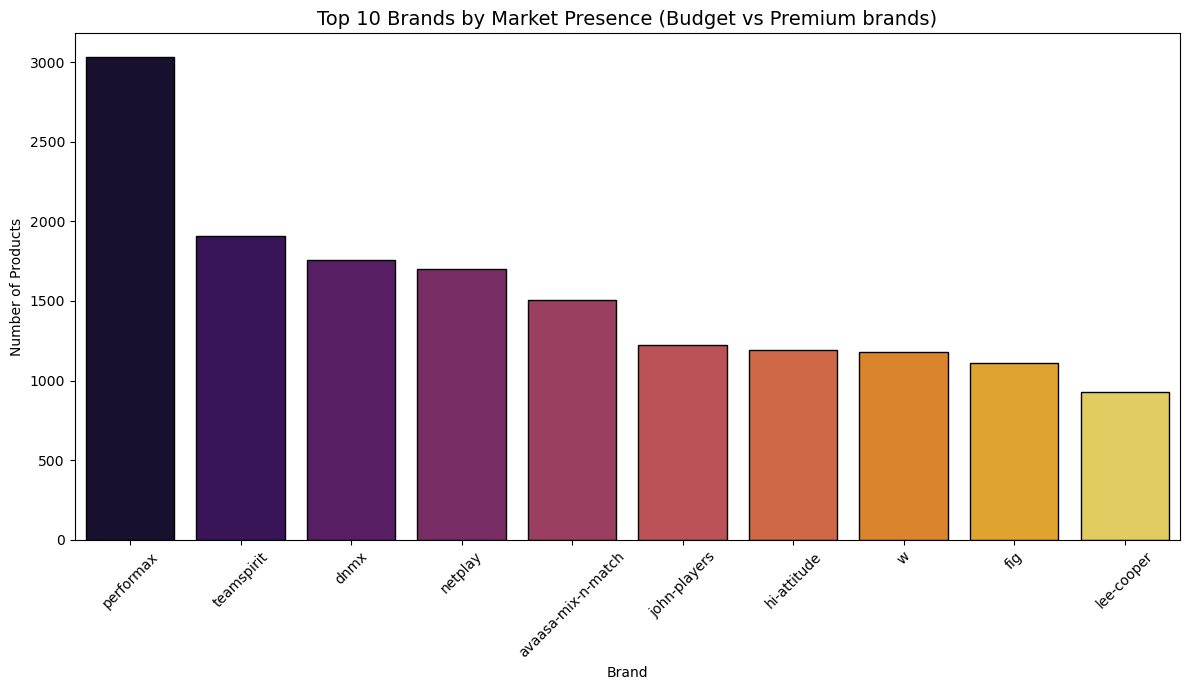

In [140]:
brand_positioning = df.groupby(["Brand", "Price_Segment"]).size().reset_index(name="Count").sort_values(["Brand", "Count"], ascending=[True, False])
top_brands =brand_positioning.groupby("Brand")["Count"].sum().sort_values(ascending=False).head(10)   
plt.figure(figsize=(12,7))
sb.barplot(x=top_brands.index,y=top_brands.values,palette="inferno",edgecolor='black')
plt.title("Top 10 Brands by Market Presence (Budget vs Premium brands)", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()